# 03 — CGAN Training

Treina um **Conditional GAN (CGAN)** para gerar imagens sintéticas de borboletas condicionadas à classe.

### Pipeline
1. Carregar dataset de treino
2. Inicializar Generator e Discriminator
3. Loop de treino adversarial com checkpoint saving
4. Visualizar amostras ao longo do treino
5. Guardar modelo final


In [15]:
import os, sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torchvision.utils as vutils
import torchvision.transforms as T
from torch.utils.data import DataLoader

# ── Paths ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(os.path.abspath("__file__")).parent
SRC_DIR      = (NOTEBOOK_DIR / "../src").resolve()
CKPT_DIR     = (NOTEBOOK_DIR / "../outputs/checkpoints/gan").resolve()
SAMPLE_DIR   = (NOTEBOOK_DIR / "../outputs/figures/gan_samples").resolve()

sys.path.insert(0, str(SRC_DIR))

CKPT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset via kagglehub (mesmo método do notebook 00) ──────────────────────
import kagglehub
dataset_path = Path(kagglehub.competition_download("aca-tp-2"))

train_dir = dataset_path / "train"
test_dir  = dataset_path / "test"
train_csv_path = dataset_path / "train.csv"

print(f"Dataset path : {dataset_path}")
print(f"Train images : {len(list(train_dir.iterdir()))} ficheiros")
print(f"Device       : ", end="")

from gan_v2 import Generator, Discriminator, build_cgan, real_label, fake_label, LATENT_DIM
from dataset import ButterflyDataset
from utils   import get_splits, GLOBAL_SEED

device = (
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(device)
torch.manual_seed(GLOBAL_SEED)


Dataset path : /Users/ritapduarte/.cache/kagglehub/competitions/aca-tp-2
Train images : 5199 ficheiros
Device       : mps


## Hiperparâmetros

In [ ]:
# ── Treino ──────────────────────────────────────────────────────────────────
NUM_EPOCHS      = 200        # epochs totais
BATCH_SIZE      = 64
LR_G            = 2e-4       # learning rate do Generator
LR_D            = 1e-4       # learning rate do Discriminator (ligeiramente menor para estabilidade)
BETA1           = 0.5        # Adam beta1 (standard para GANs)
BETA2           = 0.999      # Adam beta2
LABEL_SMOOTHING = 0.1        # suavização dos targets reais
N_CRITIC        = 1          # passos do D por cada passo de G 

# ── Modelo ──────────────────────────────────────────────────────────────────
LATENT_DIM_CFG  = 128
CLASS_EMB_DIM   = 64
NUM_CLASSES     = 75

# ── Checkpoints ─────────────────────────────────────────────────────────────
SAVE_EVERY      = 10         # guardar checkpoint a cada N epochs
N_SAMPLE_IMGS   = 75         # 1 imagem por classe nas grelhas de visualização

print("Hiperparâmetros definidos.")


Hiperparâmetros definidos.


## Dataset e DataLoader

Usa a mesma transform do autoencoder: redimensionar para 64×64 e normalizar para [-1, 1] (compatível com Tanh do G).

In [17]:
# Transform para o GAN: imagens em [-1, 1]  (Tanh no G)
gan_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),   # [-1, 1]
])

train_csv = pd.read_csv(train_csv_path)
train_df, val_df = get_splits(train_csv, seed=GLOBAL_SEED)

# Mapeamento de classes (garantir consistência com class_to_idx.json)
with open( "class_to_idx.json") as f:
    class_to_idx = json.load(f)

# Adiciona coluna label_idx ao dataframe
train_df = train_df.copy()
train_df["label_idx"] = train_df["label"].map(class_to_idx)

train_dataset = ButterflyDataset(
    train_df,
    img_dir=str(train_dir),
    transform=gan_transform,
)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=(device == "cuda"),
    drop_last=True,
)

print(f"Treino  : {len(train_dataset)} imagens | {len(train_loader)} batches por epoch")
print(f"Classes : {NUM_CLASSES}")


Treino  : 4159 imagens | 64 batches por epoch
Classes : 75


## Inicialização dos Modelos, Otimizadores e Loss

In [ ]:
G, D = build_cgan(
    latent_dim=LATENT_DIM_CFG,
    class_emb_dim=CLASS_EMB_DIM,
    num_classes=NUM_CLASSES,
    device=device,
)

optimizer_G = torch.optim.Adam(G.parameters(), lr=LR_G,  betas=(BETA1, BETA2))
optimizer_D = torch.optim.Adam(D.parameters(), lr=LR_D,  betas=(BETA1, BETA2))

# Schedulers: reduzir LR a meio do treino
scheduler_G = torch.optim.lr_scheduler.StepLR(optimizer_G, step_size=NUM_EPOCHS // 2, gamma=0.5)
scheduler_D = torch.optim.lr_scheduler.StepLR(optimizer_D, step_size=NUM_EPOCHS // 2, gamma=0.5)

criterion = nn.BCEWithLogitsLoss()   # mais estável numericamente que BCE

# Ruído fixo para visualização consistente ao longo do treino
fixed_z      = torch.randn(N_SAMPLE_IMGS, LATENT_DIM_CFG, device=device)
fixed_labels = torch.arange(NUM_CLASSES, device=device)   # 1 imagem por classe

print(G)
print("\n", D)


Generator(
  (class_emb): Embedding(75, 64)
  (fc): Linear(in_features=192, out_features=8192, bias=True)
  (deconv): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): Tanh()
  )
)

 Discriminator(
  (class_emb): Embedding(75, 64)
  (class_proj): Linear(in_features=64, out_features=4096, bias=True)
  (conv): Sequential(
    (0): Conv

## Funções Auxiliares

In [19]:
def save_checkpoint(epoch, G, D, opt_G, opt_D, losses, filename):
    """Guarda estado completo para retomar treino."""
    torch.save({
        "epoch":          epoch,
        "G_state_dict":   G.state_dict(),
        "D_state_dict":   D.state_dict(),
        "optG_state_dict": opt_G.state_dict(),
        "optD_state_dict": opt_D.state_dict(),
        "losses":         losses,
    }, filename)


def load_checkpoint(filename, G, D, opt_G, opt_D):
    """Carrega checkpoint e retorna epoch de início e histórico de losses."""
    ckpt = torch.load(filename, map_location=device)
    G.load_state_dict(ckpt["G_state_dict"])
    D.load_state_dict(ckpt["D_state_dict"])
    opt_G.load_state_dict(ckpt["optG_state_dict"])
    opt_D.load_state_dict(ckpt["optD_state_dict"])
    print(f"Checkpoint carregado: epoch {ckpt['epoch']}")
    return ckpt["epoch"] + 1, ckpt["losses"]


def save_sample_grid(G, z, labels, epoch, save_dir, nrow=15):
    """Gera e guarda uma grelha de imagens sintéticas."""
    G.eval()
    with torch.no_grad():
        imgs = G(z, labels)                          # [-1, 1]
        imgs = (imgs * 0.5 + 0.5).clamp(0, 1)       # [0, 1]
    grid = vutils.make_grid(imgs, nrow=nrow, padding=2, normalize=False)
    vutils.save_image(grid, save_dir / f"samples_epoch_{epoch:04d}.png")
    G.train()
    return grid


print("Funções auxiliares definidas.")


Funções auxiliares definidas.


## Loop de Treino

### Algoritmo CGAN por epoch:

**Passo D** (para cada batch real):
1. Forward de imagens reais com labels corretas → loss_D_real  
2. Gerar imagens falsas com labels aleatórias → loss_D_fake  
3. loss_D = (loss_D_real + loss_D_fake) / 2 → backward + step  

**Passo G** (a cada N_CRITIC passos do D):
1. Gerar imagens falsas, fazer forward no D  
2. Target = 1 (queremos enganar D) → loss_G → backward + step


In [20]:
# ── Retomar de checkpoint se existir ────────────────────────────────────────
latest_ckpt = sorted(CKPT_DIR.glob("ckpt_epoch_*.pt"))
start_epoch = 0
history = {"loss_G": [], "loss_D": [], "loss_D_real": [], "loss_D_fake": []}

if latest_ckpt:
    resume = input(f"Encontrado checkpoint: {latest_ckpt[-1].name}. Retomar? [s/N]: ").strip().lower()
    if resume == "s":
        start_epoch, history = load_checkpoint(latest_ckpt[-1], G, D, optimizer_G, optimizer_D)

# ── Treino ───────────────────────────────────────────────────────────────────
print(f"Início do treino: epochs {start_epoch} → {NUM_EPOCHS}")

for epoch in range(start_epoch, NUM_EPOCHS):
    G.train(); D.train()
    epoch_loss_G, epoch_loss_D, epoch_loss_Dr, epoch_loss_Df = 0., 0., 0., 0.
    t0 = time.time()

    for i, (real_imgs, labels) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        labels    = labels.to(device)
        batch_sz  = real_imgs.size(0)

        # ── Treinar Discriminador ─────────────────────────────────────────
        optimizer_D.zero_grad()

        # Real
        out_real  = D(real_imgs, labels)
        loss_D_r  = criterion(out_real, real_label(batch_sz, device, LABEL_SMOOTHING))

        # Falso
        z           = torch.randn(batch_sz, LATENT_DIM_CFG, device=device)
        fake_labels = torch.randint(0, NUM_CLASSES, (batch_sz,), device=device)
        fake_imgs   = G(z, fake_labels).detach()    # .detach() para não propagar para G
        out_fake    = D(fake_imgs, fake_labels)
        loss_D_f    = criterion(out_fake, fake_label(batch_sz, device))

        loss_D = (loss_D_r + loss_D_f) * 0.5
        loss_D.backward()
        optimizer_D.step()

        # ── Treinar Generator (a cada N_CRITIC passos do D) ──────────────
        if i % N_CRITIC == 0:
            optimizer_G.zero_grad()

            z           = torch.randn(batch_sz, LATENT_DIM_CFG, device=device)
            fake_labels = torch.randint(0, NUM_CLASSES, (batch_sz,), device=device)
            fake_imgs   = G(z, fake_labels)
            out_fake_g  = D(fake_imgs, fake_labels)

            # G quer que D classifique as fakes como reais
            loss_G = criterion(out_fake_g, real_label(batch_sz, device, smoothing=0.0))
            loss_G.backward()
            optimizer_G.step()

        epoch_loss_G  += loss_G.item()
        epoch_loss_D  += loss_D.item()
        epoch_loss_Dr += loss_D_r.item()
        epoch_loss_Df += loss_D_f.item()

    # ── Médias por epoch ──────────────────────────────────────────────────
    n = len(train_loader)
    history["loss_G"].append(epoch_loss_G / n)
    history["loss_D"].append(epoch_loss_D / n)
    history["loss_D_real"].append(epoch_loss_Dr / n)
    history["loss_D_fake"].append(epoch_loss_Df / n)

    scheduler_G.step()
    scheduler_D.step()

    elapsed = time.time() - t0
    print(
        f"Epoch [{epoch+1:03d}/{NUM_EPOCHS}] "
        f"loss_G={history['loss_G'][-1]:.4f}  "
        f"loss_D={history['loss_D'][-1]:.4f}  "
        f"(D_real={history['loss_D_real'][-1]:.4f}, D_fake={history['loss_D_fake'][-1]:.4f})  "
        f"[{elapsed:.1f}s]"
    )

    # ── Guardar amostras visuais ──────────────────────────────────────────
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == 0:
        save_sample_grid(G, fixed_z, fixed_labels, epoch + 1, SAMPLE_DIR)

    # ── Checkpoint periódico ──────────────────────────────────────────────
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = CKPT_DIR / f"ckpt_epoch_{epoch+1:04d}.pt"
        save_checkpoint(epoch, G, D, optimizer_G, optimizer_D, history, ckpt_path)
        print(f"  ✔ Checkpoint guardado: {ckpt_path.name}")

print("\n Treino concluído!")


Início do treino: epochs 0 → 200
Epoch [001/200] loss_G=4.0827  loss_D=0.3938  (D_real=0.4675, D_fake=0.3202)  [31.1s]
Epoch [002/200] loss_G=4.2063  loss_D=0.2702  (D_real=0.3833, D_fake=0.1571)  [30.9s]
Epoch [003/200] loss_G=3.4877  loss_D=0.4145  (D_real=0.5194, D_fake=0.3095)  [31.3s]
Epoch [004/200] loss_G=2.9283  loss_D=0.4729  (D_real=0.5714, D_fake=0.3744)  [30.8s]
Epoch [005/200] loss_G=2.3762  loss_D=0.5181  (D_real=0.6070, D_fake=0.4292)  [30.8s]
Epoch [006/200] loss_G=2.2896  loss_D=0.4935  (D_real=0.5740, D_fake=0.4131)  [30.8s]
Epoch [007/200] loss_G=2.3908  loss_D=0.5241  (D_real=0.6053, D_fake=0.4429)  [30.8s]
Epoch [008/200] loss_G=2.2301  loss_D=0.4835  (D_real=0.5686, D_fake=0.3985)  [30.9s]
Epoch [009/200] loss_G=2.1536  loss_D=0.4928  (D_real=0.5743, D_fake=0.4114)  [30.8s]
Epoch [010/200] loss_G=2.0629  loss_D=0.4877  (D_real=0.5658, D_fake=0.4096)  [30.8s]
  ✔ Checkpoint guardado: ckpt_epoch_0010.pt
Epoch [011/200] loss_G=2.0491  loss_D=0.5108  (D_real=0.5941, D

## Guardar Modelo Final

In [ ]:
# Guardar apenas os state_dicts do modelo final
torch.save(G.state_dict(), CKPT_DIR / "generator_final.pt")
torch.save(D.state_dict(), CKPT_DIR / "discriminator_final.pt")

# Guardar também um checkpoint completo final
save_checkpoint(
    NUM_EPOCHS - 1, G, D, optimizer_G, optimizer_D,
    history,
    CKPT_DIR / "ckpt_final.pt",
)

# Guardar configuração usada
config = {
    "latent_dim":      LATENT_DIM_CFG,
    "class_emb_dim":   CLASS_EMB_DIM,
    "num_classes":     NUM_CLASSES,
    "num_epochs":      NUM_EPOCHS,
    "batch_size":      BATCH_SIZE,
    "lr_G":            LR_G,
    "lr_D":            LR_D,
    "beta1":           BETA1,
    "beta2":           BETA2,
    "label_smoothing": LABEL_SMOOTHING,
    "n_critic":        N_CRITIC,
}
import json
with open(CKPT_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Modelo final guardado em:", CKPT_DIR)


Modelo final guardado em: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/outputs/checkpoints/gan


## Curvas de Loss

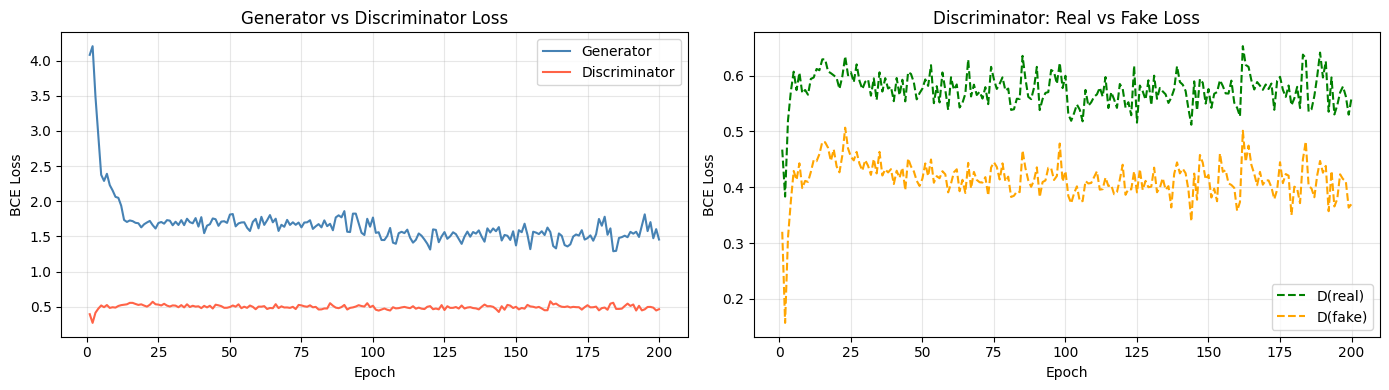

Curvas guardadas.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs_range = range(1, len(history["loss_G"]) + 1)

# Loss G vs D
axes[0].plot(epochs_range, history["loss_G"], label="Generator",     color="steelblue")
axes[0].plot(epochs_range, history["loss_D"], label="Discriminator", color="tomato")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Generator vs Discriminator Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# D decomposição
axes[1].plot(epochs_range, history["loss_D_real"], label="D(real)", color="green",  linestyle="--")
axes[1].plot(epochs_range, history["loss_D_fake"], label="D(fake)", color="orange", linestyle="--")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("BCE Loss")
axes[1].set_title("Discriminator: Real vs Fake Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAMPLE_DIR / "loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Curvas guardadas.")


## Visualização Final das Imagens Geradas

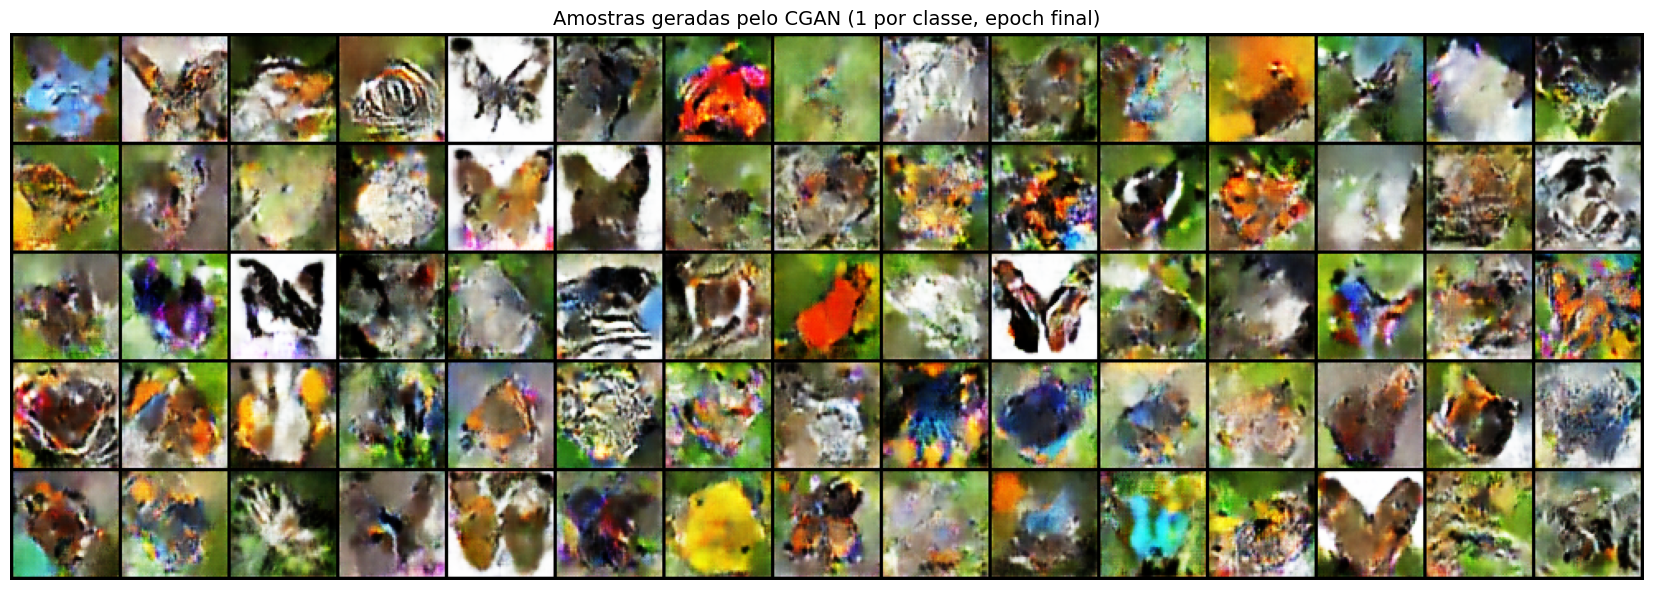

In [23]:
# Carrega o generator final e gera uma grelha de amostras
G.eval()
with torch.no_grad():
    sample_imgs = G(fixed_z, fixed_labels)
    sample_imgs = (sample_imgs * 0.5 + 0.5).clamp(0, 1).cpu()

grid = vutils.make_grid(sample_imgs, nrow=15, padding=2)
fig, ax = plt.subplots(figsize=(20, 6))
ax.imshow(grid.permute(1, 2, 0).numpy())
ax.axis("off")
ax.set_title("Amostras geradas pelo CGAN (1 por classe, epoch final)", fontsize=14)
plt.tight_layout()
plt.savefig(SAMPLE_DIR / "final_samples.png", dpi=150, bbox_inches="tight")
plt.show()


---
# Parte 04 — Gerar Dataset Aumentado

Usa o Generator treinado para criar **N imagens sintéticas por classe** e guarda-as em `data/generated/`.  
O dataset aumentado = imagens originais + imagens geradas.


In [ ]:
# ── Configuração da geração ──────────────────────────────────────────────────
N_GENERATED_PER_CLASS = 50     # imagens sintéticas a gerar por classe
GENERATED_DIR = (NOTEBOOK_DIR / "../data/generated").resolve()
AUGMENTED_DIR = (NOTEBOOK_DIR / "../data/augmented").resolve()

GENERATED_DIR.mkdir(parents=True, exist_ok=True)
AUGMENTED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Geradas em  : {GENERATED_DIR}")
print(f"Aumentado em: {AUGMENTED_DIR}")


Geradas em  : /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/data/generated
Aumentado em: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/data/augmented


In [25]:
import torchvision.transforms.functional as TF
from PIL import Image as PILImage

# Carregar o generator final (caso o treino já tenha terminado)
G.load_state_dict(torch.load(CKPT_DIR / "generator_final.pt", map_location=device))
G.eval()

idx_to_class = {v: k for k, v in class_to_idx.items()}

# Desnormalizar de [-1,1] para imagem PIL
def tensor_to_pil(t):
    t = (t * 0.5 + 0.5).clamp(0, 1)   # [-1,1] → [0,1]
    return TF.to_pil_image(t.cpu())

generated_records = []   # para o CSV do dataset aumentado

print(f"A gerar {N_GENERATED_PER_CLASS} imagens × {NUM_CLASSES} classes = "
      f"{N_GENERATED_PER_CLASS * NUM_CLASSES} imagens...")

with torch.no_grad():
    for class_idx in range(NUM_CLASSES):
        class_name = idx_to_class[class_idx]
        class_dir  = GENERATED_DIR / class_name.replace(" ", "_")
        class_dir.mkdir(parents=True, exist_ok=True)

        labels = torch.full((N_GENERATED_PER_CLASS,), class_idx,
                            dtype=torch.long, device=device)
        z      = torch.randn(N_GENERATED_PER_CLASS, LATENT_DIM_CFG, device=device)
        imgs   = G(z, labels)   # (N, 3, 64, 64)

        for j, img_t in enumerate(imgs):
            filename = f"{class_name.replace(' ', '_')}_{j:04d}.png"
            filepath = class_dir / filename
            tensor_to_pil(img_t).save(filepath)
            generated_records.append({
                "filename": str(filepath.relative_to(GENERATED_DIR.parent)),
                "label":    class_name,
            })

print(f" {len(generated_records)} imagens geradas e guardadas.")


A gerar 50 imagens × 75 classes = 3750 imagens...
 3750 imagens geradas e guardadas.


In [26]:
# ── Construir CSV do dataset aumentado ──────────────────────────────────────
# Dataset original (train_df já tem 'filename' relativo ao train_dir)
orig_df = train_df[["filename", "label"]].copy()
orig_df["filename"] = orig_df["filename"].apply(
    lambda f: str((train_dir / f).resolve())
)
orig_df["source"] = "original"

gen_df = pd.DataFrame(generated_records)
gen_df["filename"] = gen_df["filename"].apply(
    lambda f: str((GENERATED_DIR.parent / f).resolve())
)
gen_df["source"] = "generated"

augmented_df = pd.concat([orig_df, gen_df], ignore_index=True)
augmented_csv_path = AUGMENTED_DIR / "augmented_train.csv"
augmented_df.to_csv(augmented_csv_path, index=False)

print(f"Dataset aumentado: {len(augmented_df)} imagens "
      f"({len(orig_df)} originais + {len(gen_df)} geradas)")
print(f"CSV guardado em: {augmented_csv_path}")
augmented_df.head()


Dataset aumentado: 7909 imagens (4159 originais + 3750 geradas)
CSV guardado em: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/data/augmented/augmented_train.csv


,filename,label,source
0,/Users/ritapduarte/.cache/kagglehub/competitio...,PURPLE HAIRSTREAK,original
1,/Users/ritapduarte/.cache/kagglehub/competitio...,SLEEPY ORANGE,original
2,/Users/ritapduarte/.cache/kagglehub/competitio...,MONARCH,original
3,/Users/ritapduarte/.cache/kagglehub/competitio...,GREAT EGGFLY,original
4,/Users/ritapduarte/.cache/kagglehub/competitio...,SILVER SPOT SKIPPER,original


---
# Parte 05 — Re-treinar a Baseline com Dataset Aumentado

Re-treina a **BaselineCNN sem qualquer alteração** (arquitetura, otimizador e loss idênticos ao baseline original), usando apenas o dataset aumentado.


In [30]:
from models     import BaselineCNN
from transforms import get_transforms

# ── Hiperparâmetros de treino (iguais ao baseline original) ──────────────────
BASELINE_EPOCHS     = 150
BASELINE_LR         = 0.001
BASELINE_BATCH      = 32
EARLY_STOP_PATIENCE = 15

BASELINE_CKPT_DIR = (NOTEBOOK_DIR / "../outputs/checkpoints/baseline_augmented").resolve()
BASELINE_CKPT_DIR.mkdir(parents=True, exist_ok=True)

train_transform, val_transform = get_transforms()

# ── Dataset aumentado (imagens absolutas, sem img_dir prefix) ────────────────
class AugmentedDataset(torch.utils.data.Dataset):
    """Lê imagens por filepath absoluto — compatível com o CSV gerado acima."""
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        classes        = sorted(df["label"].unique())
        self.class_to_idx = {c: i for i, c in enumerate(classes)}

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = PILImage.open(row["filename"]).convert("RGB")
        if self.transform: image = self.transform(image)
        label = self.class_to_idx[row["label"]]
        return image, torch.tensor(label, dtype=torch.long)

# Split val do dataset aumentado (apenas imagens originais de val para ser justo)
_, val_df_orig = get_splits(train_csv, seed=GLOBAL_SEED)
val_df_orig = val_df_orig.copy()
val_df_orig["filename"] = val_df_orig["filename"].apply(
    lambda f: str((train_dir / f).resolve())
)

aug_train_ds = AugmentedDataset(augmented_df, transform=train_transform)
aug_val_ds   = AugmentedDataset(val_df_orig,  transform=val_transform)

aug_train_loader = DataLoader(aug_train_ds, batch_size=BASELINE_BATCH, shuffle=True,
                               num_workers=0, pin_memory=(device=="cuda"))
aug_val_loader   = DataLoader(aug_val_ds,   batch_size=BASELINE_BATCH, shuffle=False,
                               num_workers=0, pin_memory=(device=="cuda"))

print(f"Treino aumentado : {len(aug_train_ds)} imagens")
print(f"Validação        : {len(aug_val_ds)} imagens")


Treino aumentado : 7909 imagens
Validação        : 1040 imagens


In [32]:
from sklearn.metrics import f1_score, accuracy_score
from tqdm.auto import tqdm

# ── Modelo, otimizador e loss — IGUAIS ao baseline original ──────────────────
baseline_aug = BaselineCNN(num_classes=NUM_CLASSES).to(device)
optimizer_b  = torch.optim.Adam(baseline_aug.parameters(), lr=BASELINE_LR)
criterion_b  = nn.CrossEntropyLoss()

best_val_f1           = 0.0
epochs_without_improv = 0
baseline_history      = {"train_loss": [], "val_loss": [],
                          "train_acc":  [], "val_acc":  [], "val_f1": []}

print("Início do treino da Baseline com dataset aumentado...")

for epoch in range(BASELINE_EPOCHS):
    # ── Treino ────────────────────────────────────────────────────────────
    baseline_aug.train()
    trn_loss, preds_all, labels_all = 0., [], []
    for imgs, labels in tqdm(aug_train_loader,
                             desc=f"Epoch {epoch+1}/{BASELINE_EPOCHS} [Train]",
                             leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer_b.zero_grad()
        out  = baseline_aug(imgs)
        loss = criterion_b(out, labels)
        loss.backward(); optimizer_b.step()
        trn_loss += loss.item() * imgs.size(0)
        preds_all.extend(out.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    trn_loss /= len(aug_train_ds)
    trn_acc   = accuracy_score(labels_all, preds_all)

    # ── Validação ─────────────────────────────────────────────────────────
    baseline_aug.eval()
    val_loss, preds_all, labels_all = 0., [], []
    with torch.no_grad():
        for imgs, labels in tqdm(aug_val_loader,
                                 desc=f"Epoch {epoch+1}/{BASELINE_EPOCHS} [Val]",
                                 leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out       = baseline_aug(imgs)
            val_loss += criterion_b(out, labels).item() * imgs.size(0)
            preds_all.extend(out.argmax(1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    val_loss /= len(aug_val_ds)
    val_acc   = accuracy_score(labels_all, preds_all)
    val_f1    = f1_score(labels_all, preds_all, average="weighted")

    baseline_history["train_loss"].append(trn_loss)
    baseline_history["train_acc"].append(trn_acc)
    baseline_history["val_loss"].append(val_loss)
    baseline_history["val_acc"].append(val_acc)
    baseline_history["val_f1"].append(val_f1)

    print(f"Epoch {epoch+1:02d}/{BASELINE_EPOCHS} | "
          f"Train Loss: {trn_loss:.4f}  Acc: {trn_acc:.4f} || "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  F1: {val_f1:.4f}")

    # ── Early stopping por val F1 — igual ao baseline original ────────────
    if val_f1 > best_val_f1:
        best_val_f1           = val_f1
        epochs_without_improv = 0
        torch.save(baseline_aug.state_dict(),
                   BASELINE_CKPT_DIR / "baseline_augmented_best.pt")
        print(f"  ✔ Best model saved (Val F1: {best_val_f1:.4f})")
    else:
        epochs_without_improv += 1
        print(f"     No improvement for {epochs_without_improv} epoch(s).")
        if epochs_without_improv >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping após epoch {epoch+1}.")
            break

print(f"\n Melhor val F1: {best_val_f1:.4f}")

Início do treino da Baseline com dataset aumentado...


Epoch 1/150 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

Epoch 1/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 01/150 | Train Loss: 4.1307  Acc: 0.0258 || Val Loss: 4.0540  Acc: 0.0385  F1: 0.0085
  ✔ Best model saved (Val F1: 0.0085)


Epoch 2/150 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

...

Epoch 136/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 136/150 | Train Loss: 0.2665  Acc: 0.9191 || Val Loss: 0.9133  Acc: 0.7913  F1: 0.7931
     No improvement for 14 epoch(s).


Epoch 137/150 [Train]:   0%|          | 0/248 [00:00<?, ?it/s]

Epoch 137/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 137/150 | Train Loss: 0.2610  Acc: 0.9193 || Val Loss: 0.8701  Acc: 0.7923  F1: 0.7924
     No improvement for 15 epoch(s).

Early stopping após epoch 137.

 Melhor val F1: 0.8089


---
# Parte 06 — Avaliação e Plots

Calcula métricas de qualidade das imagens geradas:
- **FID** (Fréchet Inception Distance) — distância entre distribuições real e gerada (↓ melhor)
- **IS** (Inception Score) — qualidade + diversidade (↑ melhor)
- **SSIM** (Structural Similarity Index) — similaridade estrutural (↑ melhor)

E compara a performance do classificador **antes e depois** da augmentação.


In [33]:
# Instalar pytorch-fid se necessário
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "pytorch-fid", "scikit-image",
                "--quiet"], check=True)
print("Dependências instaladas.")


Dependências instaladas.


In [34]:
import warnings
warnings.filterwarnings("ignore")
from skimage.metrics import structural_similarity as ssim_fn
import torchvision.models as tv_models
import torch.nn.functional as F
from scipy import linalg

# ── Inception v3 para FID e IS ───────────────────────────────────────────────
inception = tv_models.inception_v3(weights="DEFAULT", transform_input=False).to(device)
inception.eval()

def get_inception_features(imgs_tensor):
    """Extrai features do penúltimo layer do Inception v3. imgs ∈ [0,1], (N,3,H,W)."""
    imgs_299 = F.interpolate(imgs_tensor, size=(299, 299), mode="bilinear", align_corners=False)
    with torch.no_grad():
        # Hook no avgpool para obter features 2048-d
        feats = []
        def hook(m, i, o): feats.append(o.squeeze(-1).squeeze(-1))
        h = inception.avgpool.register_forward_hook(hook)
        inception(imgs_299.to(device))
        h.remove()
    return feats[0].cpu().numpy()

def compute_fid(real_feats, fake_feats):
    """FID entre dois conjuntos de features numpy."""
    mu1, sigma1 = real_feats.mean(0), np.cov(real_feats, rowvar=False)
    mu2, sigma2 = fake_feats.mean(0), np.cov(fake_feats, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))

def compute_is(fake_feats_logits, splits=10):
    """Inception Score a partir dos logits do Inception (antes do softmax)."""
    pyx  = torch.softmax(torch.tensor(fake_feats_logits), dim=1).numpy()
    py   = pyx.mean(0)
    kl   = pyx * (np.log(pyx + 1e-8) - np.log(py + 1e-8))
    scores = np.exp(kl.sum(1))
    chunks = np.array_split(scores, splits)
    return float(np.mean([c.mean() for c in chunks])), float(np.std([c.mean() for c in chunks]))

print("Funções de avaliação definidas.")


Funções de avaliação definidas.


In [35]:
# ── Recolher features de imagens REAIS ───────────────────────────────────────
real_transform = T.Compose([T.Resize((64, 64)), T.ToTensor()])
real_sample_df = train_df.sample(min(500, len(train_df)), random_state=GLOBAL_SEED)

real_tensors = []
for _, row in real_sample_df.iterrows():
    img = PILImage.open(train_dir / row["filename"]).convert("RGB")
    real_tensors.append(real_transform(img))
real_tensors = torch.stack(real_tensors)   # (N, 3, 64, 64)

real_feats = get_inception_features(real_tensors)
print(f"Features reais: {real_feats.shape}")

# ── Gerar imagens FALSAS para avaliação ──────────────────────────────────────
G.eval()
fake_tensors = []
with torch.no_grad():
    for class_idx in range(NUM_CLASSES):
        n   = max(1, 500 // NUM_CLASSES)
        lbl = torch.full((n,), class_idx, dtype=torch.long, device=device)
        z   = torch.randn(n, LATENT_DIM_CFG, device=device)
        out = G(z, lbl)                        # [-1, 1]
        out = (out * 0.5 + 0.5).clamp(0, 1)   # [0, 1]
        fake_tensors.append(out.cpu())
fake_tensors = torch.cat(fake_tensors)   # (~500, 3, 64, 64)

fake_feats = get_inception_features(fake_tensors)
print(f"Features geradas: {fake_feats.shape}")


Features reais: (500, 2048)
Features geradas: (450, 2048)


In [36]:
# ── FID ──────────────────────────────────────────────────────────────────────
fid_score = compute_fid(real_feats, fake_feats)
print(f"FID  : {fid_score:.2f}   (↓ melhor; <50 é razoável para 64×64)")

# ── IS ───────────────────────────────────────────────────────────────────────
# Para IS precisamos dos logits completos do Inception
fake_logits = []
with torch.no_grad():
    for i in range(0, len(fake_tensors), 64):
        batch = fake_tensors[i:i+64]
        batch_299 = F.interpolate(batch, size=(299,299), mode="bilinear", align_corners=False)
        logits = inception(batch_299.to(device)).cpu().numpy()
        fake_logits.append(logits)
fake_logits = np.concatenate(fake_logits)

is_mean, is_std = compute_is(fake_logits)
print(f"IS   : {is_mean:.2f} ± {is_std:.2f}   (↑ melhor)")

# ── SSIM ─────────────────────────────────────────────────────────────────────
n_pairs = min(200, len(real_tensors), len(fake_tensors))
ssim_scores = []
for i in range(n_pairs):
    r = real_tensors[i].permute(1,2,0).numpy()
    f = fake_tensors[i].permute(1,2,0).numpy()
    ssim_scores.append(ssim_fn(r, f, data_range=1.0, channel_axis=2))

ssim_mean = float(np.mean(ssim_scores))
print(f"SSIM : {ssim_mean:.4f}   (↑ melhor; 1.0 = idêntico)")


FID  : 221.76   (↓ melhor; <50 é razoável para 64×64)
IS   : 3.18 ± 0.92   (↑ melhor)
SSIM : 0.0545   (↑ melhor; 1.0 = idêntico)


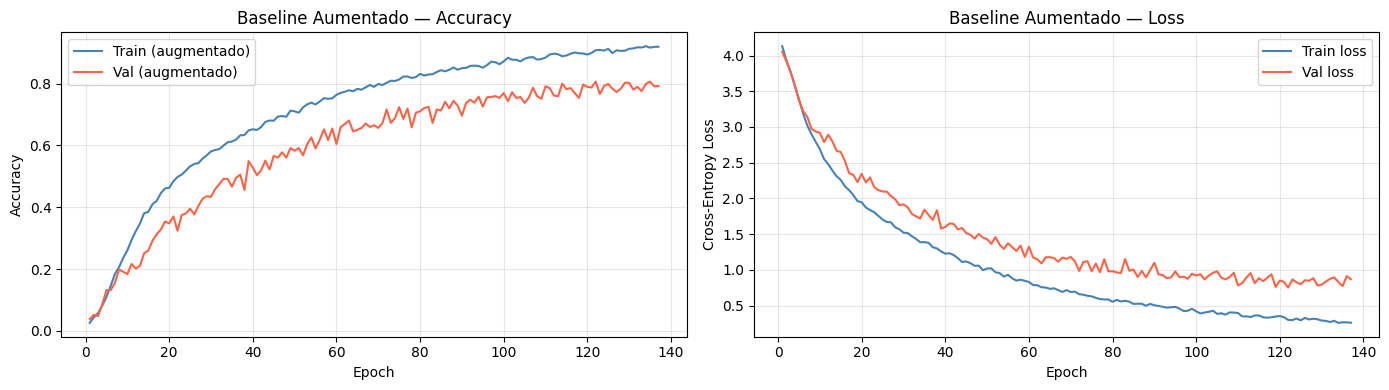


── Resumo de Métricas ──────────────────────────────────────────
  FID  (GAN)                : 221.76
  IS   (GAN)                : 3.18 ± 0.92
  SSIM (GAN vs Real)        : 0.0545
  Best val_F1 (augmentado) : 0.8089
────────────────────────────────────────────────────────────────


In [38]:
# ── Curvas de treino: Baseline original vs Baseline aumentado ─────────────────
# Nota: baseline_orig_history deve vir do notebook 01 se o correres separadamente.
# Aqui assumimos que tens baseline_history do treino acima.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs_aug = range(1, len(baseline_history["val_acc"]) + 1)

axes[0].plot(epochs_aug, baseline_history["train_acc"], label="Train (augmentado)", color="steelblue")
axes[0].plot(epochs_aug, baseline_history["val_acc"],   label="Val (augmentado)",   color="tomato")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("Baseline Aumentado — Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_aug, baseline_history["train_loss"], label="Train loss", color="steelblue")
axes[1].plot(epochs_aug, baseline_history["val_loss"],   label="Val loss",   color="tomato")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Cross-Entropy Loss")
axes[1].set_title("Baseline Aumentado — Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAMPLE_DIR / "baseline_augmented_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Tabela resumo ─────────────────────────────────────────────────────────────
print("\n── Resumo de Métricas ──────────────────────────────────────────")
print(f"  FID  (GAN)                : {fid_score:.2f}")
print(f"  IS   (GAN)                : {is_mean:.2f} ± {is_std:.2f}")
print(f"  SSIM (GAN vs Real)        : {ssim_mean:.4f}")
print(f"  Best val_F1 (augmentado) : {best_val_f1:.4f}")
print("────────────────────────────────────────────────────────────────")


---
# Parte 08 — Submissão Kaggle

Gera o ficheiro `submission.csv` com as previsões do modelo **Baseline treinado com dados aumentados** para o conjunto de teste (sem labels).


In [39]:
from models     import BaselineCNN
from transforms import get_transforms
from dataset    import ButterflyDataset

# ── Carregar o melhor modelo baseline aumentado ───────────────────────────────
BASELINE_CKPT  = (NOTEBOOK_DIR / "../outputs/checkpoints/baseline_augmented/baseline_augmented_best.pt").resolve()
SUBMISSION_DIR = (NOTEBOOK_DIR / "../outputs/submissions").resolve()
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

idx_to_class = {v: k for k, v in class_to_idx.items()}

model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(BASELINE_CKPT, map_location=device))
model.eval()
print(f"Modelo carregado: {BASELINE_CKPT.name}")


Modelo carregado: baseline_augmented_best.pt


In [40]:
# ── Dataset de teste (sem labels) ────────────────────────────────────────────
_, val_transform = get_transforms()

test_files = sorted(test_dir.iterdir())
test_df    = pd.DataFrame({"filename": [f.name for f in test_files]})

test_dataset = ButterflyDataset(
    test_df,
    img_dir=str(test_dir),
    transform=val_transform,
    is_test=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=(device == "cuda"),
)

print(f"Imagens de teste: {len(test_dataset)}")


Imagens de teste: 1300


In [41]:
# ── Inferência ────────────────────────────────────────────────────────────────
all_filenames = []
all_labels    = []

with torch.no_grad():
    for imgs, filenames in test_loader:
        imgs    = imgs.to(device)
        logits  = model(imgs)
        preds   = logits.argmax(dim=1).cpu().tolist()
        all_filenames.extend(filenames)
        all_labels.extend([idx_to_class[p] for p in preds])

print(f"Previsões geradas: {len(all_labels)}")


Previsões geradas: 1300


In [42]:
# ── Gerar CSV de submissão ────────────────────────────────────────────────────
submission_df = pd.DataFrame({
    "filename": all_filenames,
    "label":    all_labels,
})

submission_path = SUBMISSION_DIR / "submission_gan_augmented.csv"
submission_df.to_csv(submission_path, index=False)

print(f" Submissão guardada: {submission_path}")
print(f"   {len(submission_df)} linhas | {submission_df['label'].nunique()} classes distintas")
submission_df.head(10)


 Submissão guardada: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/outputs/submissions/submission_gan_augmented.csv
   1300 linhas | 75 classes distintas


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,APPOLLO
2,Image_10.jpg,PIPEVINE SWALLOW
3,Image_100.jpg,RED SPOTTED PURPLE
4,Image_1000.jpg,MALACHITE
5,Image_1001.jpg,MILBERTS TORTOISESHELL
6,Image_1002.jpg,EASTERN PINE ELFIN
7,Image_1003.jpg,CLEOPATRA
8,Image_1004.jpg,PIPEVINE SWALLOW
9,Image_1005.jpg,GREAT JAY


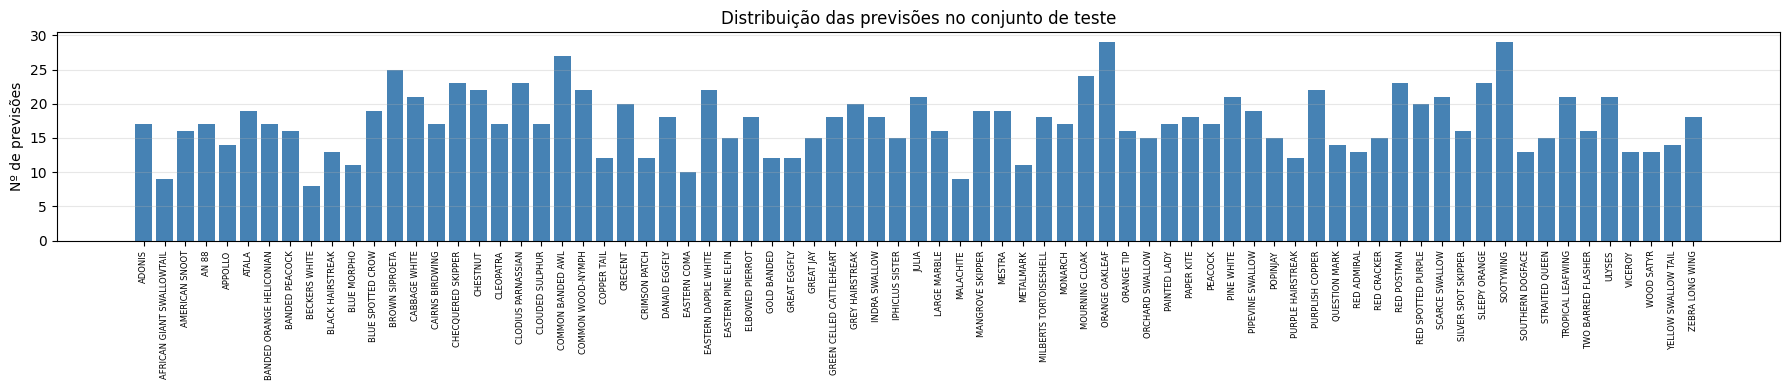

In [43]:
# ── Verificação rápida da distribuição de previsões ──────────────────────────
fig, ax = plt.subplots(figsize=(18, 4))
counts  = submission_df["label"].value_counts().sort_index()
ax.bar(range(len(counts)), counts.values, color="steelblue")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=90, fontsize=6)
ax.set_ylabel("Nº de previsões")
ax.set_title("Distribuição das previsões no conjunto de teste")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(SUBMISSION_DIR / "submission_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
